# Dreambooth

In [28]:
!git clone https://github.com/huggingface/diffusers
!cd diffusers && pip install .
!pip install xformers bitsandbytes

Cloning into 'diffusers'...
remote: Enumerating objects: 116310, done.
remote: Counting objects: 100% (761/761), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 116310 (delta 671), reused 541 (delta 535), pack-reused 115549 (from 4)
Receiving objects: 100% (116310/116310), 89.12 MiB | 10.23 MiB/s, done.
Resolving deltas: 100% (86885/86885), done.
Processing /content/diffusers
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.37.0.dev0-py3-none-any.whl size=4830827 sha256=b407d4db47b9abe56364037d6cdd42f25582dbfb9ee1a2639b9b108d88effde9
  Stored in directory: /tmp/pip-ephem-wheel-cache-isufwrlm/wheels/8a/fc/09/385efb77b455b2fd4a656c950079c93147e1f50ae614e51beb
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.36.0
    Uninstalling diffusers-0.36.0:
      Successfully uninst

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

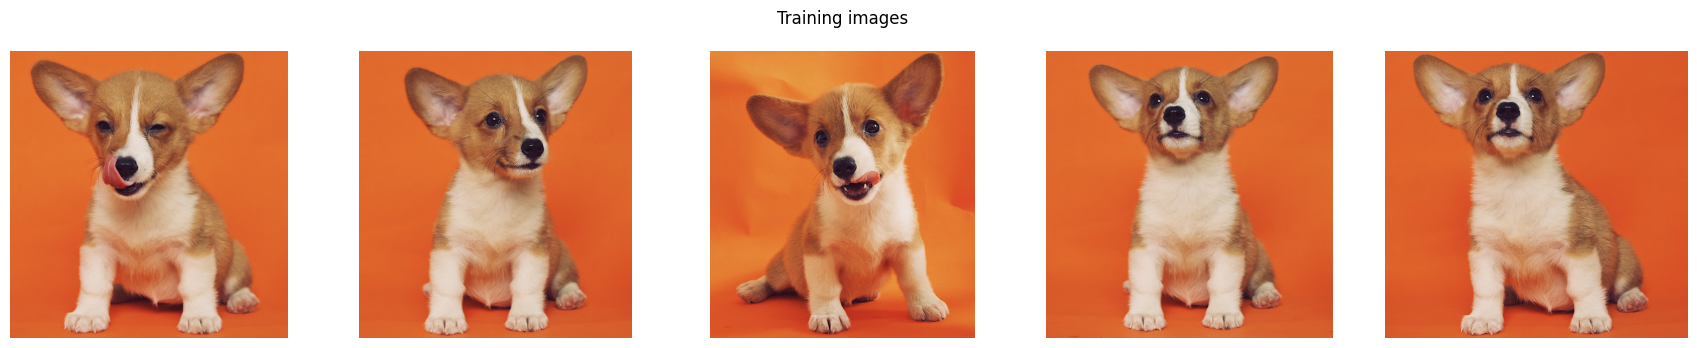

In [27]:
from huggingface_hub import snapshot_download
from PIL import Image
import matplotlib.pyplot as plt
import os

local_dir = "./dog"
snapshot_download(
    "diffusers/dog-example",
    local_dir=local_dir,
    repo_type="dataset",
    ignore_patterns=".gitattributes",
)

data_dir = "/content/dog"
filelist = os.listdir(data_dir)
filelist = [f for f in filelist if f.endswith(".jpeg")]
fig, ax = plt.subplots(1, len(filelist), figsize=(len(filelist) * 3.5, 3.5))
for n, img in enumerate(filelist):
    img = Image.open(os.path.join(data_dir, img))
    ax[n].axis("off")
    ax[n].imshow(img)
fig.suptitle("Training images")
plt.tight_layout()
plt.show()

In [35]:
!rm -rf /content/dog/.cache

In [36]:
os.environ["MODEL_NAME"] = "stable-diffusion-v1-5/stable-diffusion-v1-5"
os.environ["INSTANCE_DIR"] = "/content/dog"
os.environ["OUTPUT_DIR"] = "/content/dreambooth_model_output"

!accelerate launch /content/diffusers/examples/dreambooth/train_dreambooth.py \
  --use_8bit_adam \
  --gradient_checkpointing \
  --enable_xformers_memory_efficient_attention \
  --set_grads_to_none \
  --pretrained_model_name_or_path=$MODEL_NAME  \
  --instance_data_dir=$INSTANCE_DIR \
  --validation_prompt="a photo of a sks dog" \
  --instance_prompt="a photo of a sks dog" \
  --num_validation_images=4 \
  --validation_steps=100 \
  --output_dir=$OUTPUT_DIR \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=5e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=400

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-01-09 13:38:08.257276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767965888.283340    6599 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767965888.297072    6599 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767965888.315842    6599 computation_plac

Training time: 21 minutes

In [50]:
!zip -r /content/drive/MyDrive/dreambooth_model_output.zip /content/dreambooth_model_output

  adding: content/dreambooth_model_output/ (stored 0%)
  adding: content/dreambooth_model_output/model_index.json (deflated 57%)
  adding: content/dreambooth_model_output/tokenizer/ (stored 0%)
  adding: content/dreambooth_model_output/tokenizer/merges.txt (deflated 60%)
  adding: content/dreambooth_model_output/tokenizer/vocab.json (deflated 71%)
  adding: content/dreambooth_model_output/tokenizer/tokenizer_config.json (deflated 63%)
  adding: content/dreambooth_model_output/tokenizer/special_tokens_map.json (deflated 73%)
  adding: content/dreambooth_model_output/vae/ (stored 0%)
  adding: content/dreambooth_model_output/vae/diffusion_pytorch_model.safetensors (deflated 7%)
  adding: content/dreambooth_model_output/vae/config.json (deflated 56%)
  adding: content/dreambooth_model_output/unet/ (stored 0%)
  adding: content/dreambooth_model_output/unet/diffusion_pytorch_model.safetensors

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access '__iter__' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):





zip error: Interrupted (aborting)



In [41]:
from diffusers import DiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel
import torch

unet = UNet2DConditionModel.from_pretrained("/content/dreambooth_model_output/unet")

# if you have trained with `--args.train_text_encoder` make sure to also load the text encoder
text_encoder = CLIPTextModel.from_pretrained("/content/dreambooth_model_output/text_encoder")

pipeline = DiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", unet=unet, text_encoder=text_encoder, dtype=torch.float16,
).to("cuda")

prompts = ["A picture of a sks dog laying on a couch", "A picture of a sks dog in crochet style", "A picture of a sks dog in a grocery store aisle"]
for n, prompt in enumerate(prompts):
    image = pipeline(prompt, num_inference_steps=50, guidance_scale=7.5, generator=torch.manual_seed(0)).images[0]
    image.save(f"sks_style_image_dreambooth_{n}.png")

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
torch.cuda.empty_cache()

In [42]:
pipeline = DiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
).to("cuda")

for n, prompt in enumerate(prompts):
    image = pipeline(prompt, num_inference_steps=50, guidance_scale=7.5, generator=torch.manual_seed(0)).images[0]
    image.save(f"sks_style_image_{n}.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

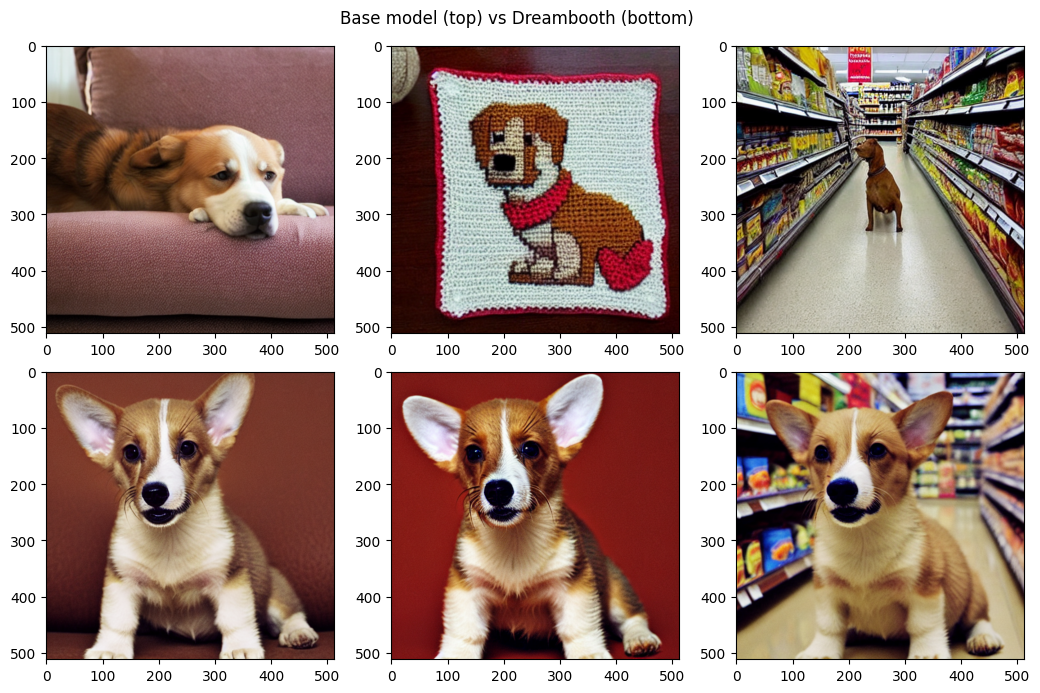

In [48]:
data_dir = "/content/"
fig, ax = plt.subplots(2, 3, figsize=(3 * 3.5, 7))
for n in range(len(prompts)):
    img_orig = Image.open(data_dir + f"sks_style_image_{n}.png")
    img_dreambooth = Image.open(data_dir + f"sks_style_image_dreambooth_{n}.png")
    ax[0, n].imshow(img_orig)
    ax[1, n].imshow(img_dreambooth)
fig.suptitle("Base model (top) vs Dreambooth (bottom)")
plt.tight_layout()
plt.show()